In [1]:
!pip install librosa

In [3]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

In [4]:
emotion_dict = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised"
}

In [5]:
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    return np.mean(mfcc.T, axis=0)

In [8]:
import os

print(os.listdir("/content"))

['.config', 'archive (1).zip', 'sample_data']


In [10]:
!unzip "/content/archive (1).zip" -d "/content/RAVDESS"

Archive:  /content/archive (1).zip
  inflating: /content/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: /content/RAVDESS/Actor_01/03-01-03-01-01-02-01.wav  
  inflating: /content/RAVDESS/Actor_01/03

In [11]:
import os

print(os.listdir("/content/RAVDESS"))

['Actor_23', 'Actor_10', 'Actor_20', 'Actor_15', 'Actor_22', 'Actor_08', 'Actor_12', 'Actor_02', 'Actor_17', 'Actor_07', 'Actor_04', 'Actor_14', 'Actor_24', 'Actor_11', 'Actor_18', 'Actor_19', 'Actor_13', 'Actor_09', 'Actor_16', 'Actor_06', 'Actor_05', 'audio_speech_actors_01-24', 'Actor_01', 'Actor_21', 'Actor_03']


In [12]:
features = []
labels = []

dataset_path = "/content/RAVDESS"

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.endswith(".wav"):

                emotion = emotion_dict[file.split("-")[2]]

                file_path = os.path.join(folder_path, file)

                mfcc = extract_features(file_path)

                features.append(mfcc)

                labels.append(emotion)

In [13]:
X = np.array(features)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train = X_train.reshape(X_train.shape[0],40,1)

X_test = X_test.reshape(X_test.shape[0],40,1)

In [16]:
model = Sequential()

model.add(Conv1D(64,3,activation='relu',input_shape=(40,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128,3,activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(y.shape[1],activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1615 - loss: 3.4474 - val_accuracy: 0.1806 - val_loss: 2.0035
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1710 - loss: 2.0356 - val_accuracy: 0.1493 - val_loss: 1.9746
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1771 - loss: 1.9815 - val_accuracy: 0.2118 - val_loss: 1.9366
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2109 - loss: 1.9750 - val_accuracy: 0.2465 - val_loss: 1.9325
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2161 - loss: 1.9558 - val_accuracy: 0.2465 - val_loss: 1.8793
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2465 - loss: 1.9020 - val_accuracy: 0.2986 - val_loss: 1.8598
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2569 - loss: 1.8851 - val_accuracy: 0.3264 - val_loss: 1.8291
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2387 - loss: 1.8929 - val_accuracy: 0.3229 - v

In [19]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Accuracy:",accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4514 - loss: 1.4598 
Accuracy: 0.4513888955116272


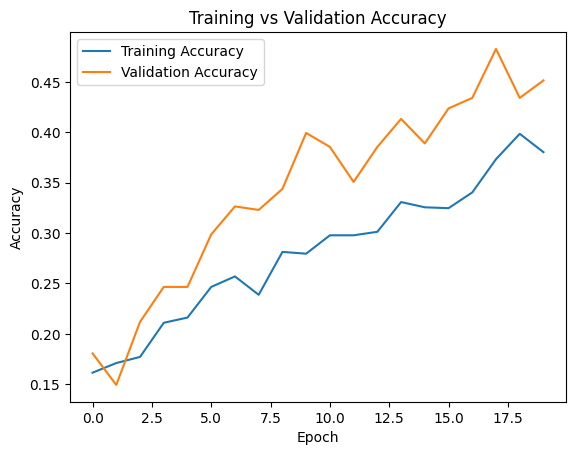

In [20]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [21]:
model.save("emotion_recognition_model.h5")